# Exercício:

## 01 – Do exercício 2 da aula 15, exporte o objeto DataFrame contendo as frequências absolutas de cada aminoácido em cada proteína para .csv, instancie um objeto da classe DataFrame. Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas de tendência central. Qual o valor de média, mediana e moda da Serina nos genes analisados? E do terceiro gene?

In [1]:
import pandas as pd
import numpy as np
from Bio import Entrez
import time
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [3]:
df_aminos = pd.read_csv("df_amino.csv")
df_aminos

,gene,A,C,D,E,F,G,H,I,K,...,M,N,P,Q,R,S,T,V,W,Y
0,PPARG,26,10,32,32,26,19,14,33,39,...,15,15,23,23,19,34,22,24,1,18
1,ADRB2,25,13,16,19,25,28,11,31,16,...,10,22,12,19,17,29,23,36,8,14
2,TCF7L2,42,9,26,35,11,35,28,19,40,...,11,20,79,34,28,69,29,22,5,17
3,FABP2,5,0,8,13,8,10,1,7,14,...,3,11,0,2,7,5,11,11,2,4
4,NOTCH2,171,243,152,129,59,219,76,79,72,...,47,143,181,118,92,181,135,119,19,65


In [9]:
def med_tend_central(dados):
    """
    Recebe um objeto unidimensional (lista, array, Series)
    e retorna média, mediana e moda.
    """
    serie = pd.Series(dados).dropna()

    media = serie.mean()
    mediana = serie.median()
    moda = serie.mode()
    
    return {
        "media": media,
        "mediana": mediana,
        "moda": moda.values.tolist()
    }

In [10]:
dados = df_aminos["S"]
print(med_tend_central(dados))

{'media': np.float64(63.6), 'mediana': np.float64(34.0), 'moda': [5, 29, 34, 69, 181]}


In [19]:
dados = df_aminos.loc[[2], "C"]
print(med_tend_central(dados))

{'media': np.float64(9.0), 'mediana': np.float64(9.0), 'moda': [9]}


## 02 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a amplitude. Qual o valor de amplitude da Isoleucina? E do último gene?

In [28]:
print(df_aminos.index.tolist())

[0, 1, 2, 3, 4]


In [36]:
def amplitude(dados):
    serie = pd.Series(dados)
    serie = pd.to_numeric(serie, errors="coerce").dropna()
    return serie.max() - serie.min()
amplitude(df_aminos["I"])

np.int64(72)

In [37]:
amplitude(df_aminos.loc[4, :])

np.float64(224.0)

## 03 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne os quartis. Qual o valor do Q1, Q2 e Q3 da Metionina? E do primeiro gene?

In [ ]:
def quartis(dados):
    serie = pd.Series(dados).dropna()
    serie = pd.to_numeric(serie, errors="coerce").dropna()
    return {
        "Q1": serie.quantile(0.25),
        "Q2 (mediana)": serie.quantile(0.5),
        "Q3": serie.quantile(0.75)
    }
quartis(df_aminos["M"])

{'Q1': np.float64(17.25),
 'Q2 (mediana)': np.float64(23.0),
 'Q3': np.float64(32.0)}

In [41]:
quartis(df_aminos.loc[0, :])

{'Q1': np.float64(17.25),
 'Q2 (mediana)': np.float64(23.0),
 'Q3': np.float64(32.0)}

## 04 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o intervalo interquartil. Qual o valor do o intervalo interquartil da Ácido Glutâmico? E do penúltimo gene? Obtenha o box plot com as medidas de tendência central para a frequência de aa nesse gene.

In [45]:
def intervalo_interquartil(dados):
    serie = pd.Series(dados).dropna()
    serie = pd.to_numeric(serie, errors="coerce").dropna()
    return serie.quantile(0.75) - serie.quantile(0.25)
intervalo_interquartil(df_aminos["E"])

np.float64(16.0)

In [46]:
intervalo_interquartil(df_aminos.loc[3, :])

np.float64(7.5)

## 05 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a variância amostral não viciada. Qual o valor da variância da Prolina? E do terceiro gene?

In [48]:
def variancia_amostral(dados):
    serie = pd.Series(dados).dropna()
    serie = pd.to_numeric(serie, errors="coerce").dropna()
    return serie.var(ddof=1)
variancia_amostral(df_aminos["P"])

np.float64(5567.5)

In [50]:
variancia_amostral(df_aminos.loc[2, :])

np.float64(388.4710526315789)

## 06 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o desvio padrão. Qual o valor d o desvio padrão do Triptofano? E do gene de index -1?

In [ ]:
def desvio_padrao(dados):
    serie = pd.Series(dados).dropna()
    serie = pd.to_numeric(serie, errors="coerce").dropna()
    return serie.std(ddof=1)
desvio_padrao(df_aminos["W"])

np.float64(7.245688373094719)

In [53]:
desvio_padrao(df_aminos.iloc[-1, :])

np.float64(59.89769787334331)

## 07 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o coeficiente de variação. Qual o valor do coeficiente de variação da Leucina? E do gene de index 1?

In [58]:
def coeficiente_variacao(dados):
    serie = pd.Series(dados).dropna()
    serie = pd.to_numeric(serie, errors="coerce").dropna()
    media = serie.mean()
    desvio = serie.std(ddof=1)   
    if media == 0:
        return np.nan
    return desvio / media
coeficiente_variacao(df_aminos["L"])

np.float64(0.933448930267647)

In [59]:
coeficiente_variacao(df_aminos.iloc[1, :])

np.float64(0.4237087872345249)

## 08 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas resumo.
Obs.: Use um dicionário onde os index são os nomes e os valores as medidas.

In [61]:
def medidas_resumo(dados):
    serie = pd.Series(dados).dropna()
    
    resumo = {
        "media": serie.mean(),
        "mediana": serie.median(),
        "amplitude": amplitude(serie),
        "variancia": variancia_amostral(serie),
        "desvio_padrao": desvio_padrao(serie),
        "CV": coeficiente_variacao(serie),
        "Q1": serie.quantile(0.25),
        "Q3": serie.quantile(0.75),
        "IQR": intervalo_interquartil(serie)
    }
    
    return resumo

medidas_resumo(df_aminos["S"])

{'media': np.float64(63.6),
 'mediana': np.float64(34.0),
 'amplitude': np.int64(176),
 'variancia': np.float64(4829.800000000001),
 'desvio_padrao': np.float64(69.49676251452294),
 'CV': np.float64(1.092716391737782),
 'Q1': np.float64(29.0),
 'Q3': np.float64(69.0),
 'IQR': np.float64(40.0)}

## 09 – Defina uma função que retorne qual o gene com o maior CV de frequência de aminoácidos. Obtenha os boxplot dos genes. Os dados concordam? Porque?

(3, np.float64(0.6657235608387329))


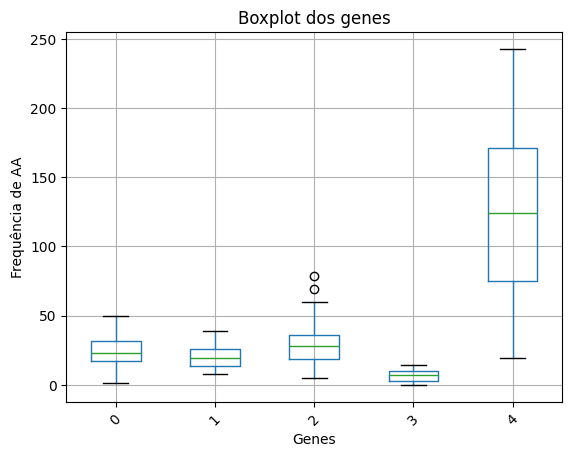

In [66]:
def gene_com_maior_cv(df):
    cvs = df.apply(coeficiente_variacao, axis=1)
    
    gene = cvs.idxmax()
    
    return gene, cvs[gene]
print(gene_com_maior_cv(df_aminos))


df_aminos.select_dtypes(include="number").T.boxplot()
plt.title("Boxplot dos genes")
plt.xlabel("Genes")
plt.ylabel("Frequência de AA")
plt.xticks(rotation=45)
plt.show()


In [67]:
df_aminos["media"] = df_aminos.select_dtypes(include="number").mean(axis=1)
df_aminos["desvio"] = df_aminos.select_dtypes(include="number").std(axis=1)

print(df_aminos[["media", "desvio"]])

    media     desvio
0   23.75  10.713893
1   20.65   8.528042
2   30.95  19.210609
3    6.60   4.282523
4  123.55  58.381054


R: Com base na função, o gene que apresenta o maior coeficiente de variação é o FABP2, no entanto, quando olhamos o boxplot a menor variação parece estar nesse gene. Isso se deve a uma falsa noção dada pela variação relativa obtida pelo coeficiente de variânica.

## 10 – Defina uma função que retorne qual o aminoácidos com o maior CV dentre os genes. Obtenha os boxplot dos aminoácidos. Os dados concordam? Porque?

In [68]:
def aminoacido_com_maior_cv(df):
    cvs = df.apply(coeficiente_variacao, axis=0)
    aa = cvs.idxmax()
    return aa, cvs[aa]
aminoacido_com_maior_cv(df_aminos)

('C', np.float64(1.9128534351755258))

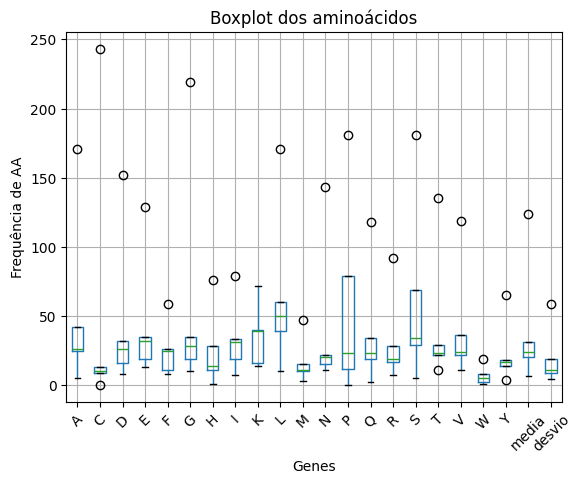

In [70]:
df_aminos.select_dtypes(include="number").boxplot()
plt.title("Boxplot dos aminoácidos")
plt.xlabel("Genes")
plt.ylabel("Frequência de AA")
plt.xticks(rotation=45)
plt.show()

R: O mesmo que ocorre no caso anterior dos genes, ocorre com os aminoácidos. No coeficiente de variação avaliamos somente uma variação relativa à média, enquanto o boxplot mostra a variação absoluta dos valores.